# Problem Statement

Mục tiêu của phần này là sử dụng phương pháp PCA (Principal Component Analysis)
để phân tích cấu trúc biến động của thị trường chứng khoán Việt Nam (VN30).

Cụ thể:
- Giảm chiều dữ liệu từ 30 cổ phiếu xuống các thành phần chính
- Phân tích thành phần chính đầu tiên (PC1)
- So sánh PC1 với chỉ số VN30-Index

## Ý nghĩa tài chính
PCA giúp xác định liệu thị trường có bị chi phối bởi một yếu tố chung hay không.

#PHẦN 1: THU THẬP VÀ XỬ LÝ DỮ LIỆU

#  Data Collection

- Thu thập dữ liệu giá đóng cửa của 30 cổ phiếu VN30
- Thu thập dữ liệu VN30-Index
- Khoảng thời gian: Từ 01-04-2025 đến 01-04-2026

Nguồn dữ liệu:
- 30 cổ phiếu thuộc rổ VN30: Dùng thư viện 'yfinance'.
- Chỉ số VN30: Thu thập bằng cách download file csv trên 'Investing.com'. Do chỉ số này không được cung cấp ổn định và nhất quán trên các API miễn phí.

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

# 1. Danh sách 30 mã VN30
tickers = [
    "ACB.VN", "BCM.VN", "BID.VN", "BVH.VN", "CTG.VN", "FPT.VN", "GAS.VN", "GVR.VN",
    "HDB.VN", "HPG.VN", "MBB.VN", "MSN.VN", "MWG.VN", "PLX.VN", "POW.VN", "SAB.VN",
    "SHB.VN", "SSB.VN", "SSI.VN", "STB.VN", "TCB.VN", "TPB.VN", "VCB.VN", "VHM.VN",
    "VIB.VN", "VIC.VN", "VJC.VN", "VNM.VN", "VPB.VN", "VRE.VN"
]

# 2. Tải 30 mã cổ phiếu trước
print("Đang tải 30 cổ phiếu...")
data_stocks = yf.download(tickers, start="2025-04-01", end="2026-04-01")
df_stock_raw = data_stocks['Close'].copy()

# 3. Tải VN30 Index và ép khớp vào df
print("Đang đọc VN30 Index từ CSV...")

df_index_raw = pd.read_csv("/content/VN30_Historical_Data.csv")

Đang tải 30 cổ phiếu...


/tmp/ipykernel_9399/1737938402.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_stocks = yf.download(tickers, start="2025-04-01", end="2026-04-01")
[*********************100%***********************]  30 of 30 completed


Đang đọc VN30 Index từ CSV...


# Data Preprocessing

- Gộp dữ liệu các cổ phiếu
- Đồng bộ ngày giao dịch
- Xử lý missing values

In [ ]:
df = df_stock_raw.copy()

# Chuẩn hóa Index của cổ phiếu (Xóa múi giờ)
df.index = pd.to_datetime(df.index).tz_localize(None)

# Chỉnh lại đúng cột
df_idx = df_index_raw[['Date', 'Price']]
df_idx.columns = ['date', 'VN30_Index']

df_idx['date'] = pd.to_datetime(df_idx['date'])

# Xử lý số nếu có dấu phẩy
df_idx['VN30_Index'] = (
    df_idx['VN30_Index']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)
# Đưa index về cột date
df = df.reset_index()

# Chuẩn hoá tên cột ngày
df = df.rename(columns={df.columns[0]: 'date'})

# Merge VN30 Index thật
df = pd.merge(df, df_idx, on='date', how='inner')

# Set lại index
df = df.set_index('date')

# 4. Làm sạch dữ liệu
# Xóa .VN ở tên cột
df.columns = [col.replace(".VN", "") for col in df.columns]

# Điền các ô trống (NaN) nếu có
df = df.dropna()

# Làm tròn
df = df.round(2)

# 5. KIỂM TRA BẰNG LỆCH COUNT
print("\n--- KẾT QUẢ ---")
print(f"Số lượng cột (phải là 31): {len(df.columns)}")
print(f"Số lượng ô có số ở hàng cuối: {df.iloc[-1].count()}")


--- KẾT QUẢ ---
Số lượng cột (phải là 31): 31
Số lượng ô có số ở hàng cuối: 31


/tmp/ipykernel_9399/3308989878.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idx['date'] = pd.to_datetime(df_idx['date'])
/tmp/ipykernel_9399/3308989878.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idx['VN30_Index'] = (


In [ ]:
# 6. Lưu file (Note: Nếu cần tải file csv về cho mục đích khác thì vui lòng xóa dấu "#" ở 3 câu lệnh dưới)
#from google.colab import files

#df.to_csv("VN30_data_final.csv")
#files.download("VN30_data_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Calculate Daily Returns

Sử dụng tỷ suất sinh lợi thay vì giá để phản ánh biến động thị trường.

In [ ]:
returns = df.pct_change().dropna()

Trong bài toán này, nhóm sử dụng simple return để phản ánh biến động giá cổ phiếu.

Ngoài ra, log return cũng là một lựa chọn phổ biến trong tài chính do có tính chất cộng dồn theo thời gian. Tuy nhiên, với dữ liệu theo ngày, sự khác biệt giữa simple return và log return là không đáng kể, do đó simple return được lựa chọn để giữ tính trực quan và dễ diễn giải.

In [ ]:
#Tách VN30_Index ra khỏi return
vn30_return = returns['VN30_Index']
stock_returns = returns.drop(columns=['VN30_Index'])


Sau khi tính toán daily return, dữ liệu bao gồm cả các cổ phiếu VN30 và chỉ số VN30-Index.

Tuy nhiên, trong quá trình áp dụng PCA, chỉ các cổ phiếu riêng lẻ được sử dụng làm biến đầu vào.
Chỉ số VN30-Index được giữ lại như một biến tham chiếu (benchmark) để so sánh với thành phần chính (PC1) sau này.

Việc tách này giúp đảm bảo rằng PCA thực sự trích xuất yếu tố thị trường từ dữ liệu cổ phiếu, thay vì bị ảnh hưởng trực tiếp bởi chỉ số VN30.

#PHẦN 2: XÂY DỰNG PCA

#  Data Standardization

Chuẩn hóa dữ liệu để đảm bảo trung bình = 0 và độ lệch chuẩn = 1.

Trước khi áp dụng PCA, dữ liệu cần được chuẩn hóa để đảm bảo các biến có cùng thang đo.

Mặc dù đã sử dụng daily return (đã là phần trăm), các cổ phiếu vẫn có mức độ biến động khác nhau.
Do đó, việc chuẩn hóa giúp mỗi cổ phiếu có trung bình bằng 0 và độ lệch chuẩn bằng 1, tránh việc các cổ phiếu có biến động lớn chi phối kết quả PCA.

In [ ]:
X = (stock_returns - stock_returns.mean()) / stock_returns.std()

In [ ]:
# Check trung bình và độ lệch chuẩn:
X.mean().mean(), X.std().mean()

(np.float64(-8.6993690104316e-19), np.float64(1.0))

In [ ]:
print("Mean từng cột:")
print(X.mean().head())

print("\nStd từng cột:")
print(X.std().head())

Mean từng cột:
ACB    2.022674e-18
BCM    3.371123e-17
BID   -3.034010e-18
BVH    1.348449e-17
CTG    4.449882e-17
dtype: float64

Std từng cột:
ACB    1.0
BCM    1.0
BID    1.0
BVH    1.0
CTG    1.0
dtype: float64


#  Covariance Matrix

Đo lường mức độ biến động cùng nhau giữa các cổ phiếu.

Nếu covariance dương, hai cổ phiếu có xu hướng tăng/giảm cùng nhau.
Nếu covariance âm, hai cổ phiếu có xu hướng biến động ngược chiều.

Đây là cơ sở để PCA xác định các thành phần chính trong dữ liệu.

In [ ]:
import numpy as np

cov_matrix = np.cov(X.T)
print("Kỳ vọng là (30,30) do có 30 cổ phiếu")
print(cov_matrix.shape)

Kỳ vọng là (30,30) do có 30 cổ phiếu
(30, 30)


Ma trận covariance có kích thước (30, 30), tương ứng với 30 cổ phiếu.

Mỗi phần tử trong ma trận thể hiện mức độ đồng biến giữa hai cổ phiếu sau khi đã chuẩn hóa.

#  Eigenvalues & Eigenvectors


Eigenvalues thể hiện mức độ quan trọng (phương sai) của từng thành phần chính.

Eigenvectors xác định hướng của các thành phần chính trong không gian dữ liệu.

Trong PCA, các eigenvector tương ứng với eigenvalue lớn nhất sẽ đại diện cho các thành phần chính quan trọng nhất.

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues[:5]

array([13.04189639,  2.63638267,  1.92767846,  1.21546269,  0.9797715 ])

In [ ]:
#Check tổng eigenvalues: Tổng eigenvalues = tổng variance
print("Tổng eigenvalues:", np.sum(eigenvalues))

Tổng eigenvalues: 30.000000000000014


#  Sort Principal Components

Các eigenvalues và eigenvectors được sắp xếp theo thứ tự giảm dần để xác định các thành phần chính quan trọng nhất.

In [ ]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [ ]:
#Check xem Eigenvalues đã sort giảm dần chưa
print("Eigenvalues đã giảm dần chưa:")
print(eigenvalues[:10])

Eigenvalues đã giảm dần chưa:
[13.04189639  2.63638267  1.92767846  1.21546269  0.9797715   0.94640882
  0.88580324  0.70964932  0.67919726  0.61725022]


#  Explained Variance

Explained variance cho biết mỗi thành phần chính (principal component) giữ lại bao nhiêu phần trăm thông tin (phương sai) của dữ liệu ban đầu.

Thông qua chỉ số này, có thể xác định số lượng thành phần chính cần thiết để mô tả phần lớn biến động của thị trường.

Thành phần có explained variance cao hơn sẽ đóng vai trò quan trọng hơn trong việc giải thích dữ liệu.

In [ ]:
explained_variance = eigenvalues / np.sum(eigenvalues)
explained_variance[:5]

array([0.43472988, 0.08787942, 0.06425595, 0.04051542, 0.03265905])

#  Cumulative Explained Variance

Cumulative explained variance cho biết tổng lượng thông tin được giữ lại khi kết hợp nhiều thành phần chính.

Chỉ số này giúp xác định số lượng thành phần chính cần thiết để mô tả phần lớn dữ liệu.

In [ ]:
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance[:5]

array([0.43472988, 0.5226093 , 0.58686525, 0.62738067, 0.66003972])

Kết quả cho thấy chỉ với một số ít thành phần chính đầu tiên đã có thể giải thích phần lớn biến động của dữ liệu, cho thấy khả năng giảm chiều hiệu quả của PCA.

# Scree Plot

Biểu đồ Scree Plot giúp trực quan hóa mức độ đóng góp của từng thành phần chính.

Thông qua biểu đồ này, có thể xác định điểm "gãy" (elbow) để chọn số lượng thành phần phù hợp.

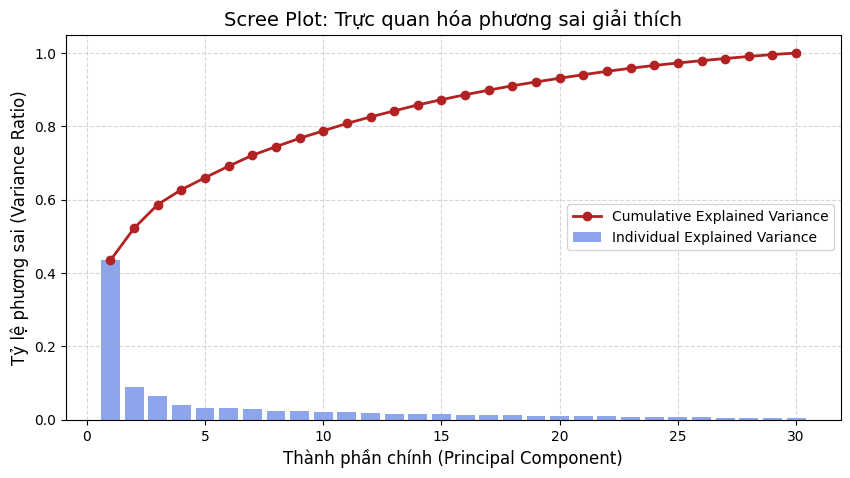

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Biểu đồ cột cho Explained Variance
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, color='royalblue', label='Individual Explained Variance')
# Biểu đồ đường cho Cumulative Variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='firebrick', linewidth=2, label='Cumulative Explained Variance')

plt.title("Scree Plot: Trực quan hóa phương sai giải thích", fontsize=14)
plt.xlabel("Thành phần chính (Principal Component)", fontsize=12)
plt.ylabel("Tỷ lệ phương sai (Variance Ratio)", fontsize=12)
plt.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Scree Plot cho thấy phần lớn phương sai của dữ liệu được giải thích bởi một số ít thành phần đầu tiên, trong đó PC1 chiếm tỷ trọng lớn nhất.

Điều này cho thấy biến động của các cổ phiếu trong VN30 không hoàn toàn độc lập, mà chịu ảnh hưởng bởi một số ít yếu tố chung.

Về mặt tài chính, kết quả này hàm ý rằng thị trường có tính đồng biến cao và bị chi phối bởi một “market factor” chính, thay vì mỗi cổ phiếu biến động riêng lẻ.

#PHẦN 3: PHÂN TÍCH VÀ TRỰC QUAN HÓA PC1

# First Principal Component (PC1)

Sau khi xác định các eigenvectors, thành phần chính đầu tiên (PC1) được xây dựng bằng cách chiếu dữ liệu đã chuẩn hóa lên eigenvector tương ứng với eigenvalue lớn nhất.

PC1 đại diện cho thành phần giải thích nhiều biến động nhất.

In [ ]:
PC1 = X @ eigenvectors[:, 0]

In [ ]:
PC1.mean(), PC1.std()

(np.float64(2.8766912378951425e-17), 3.611356585876569)

Ở bước này, PC1 được tạo ra như một chuỗi thời gian mới đại diện cho sự kết hợp tuyến tính của 30 cổ phiếu.

Giá trị trung bình của PC1 gần bằng 0 và có độ biến động khác 0, cho thấy phép biến đổi đã được thực hiện hợp lệ và dữ liệu có sự thay đổi theo thời gian.

Các phân tích sâu hơn về mức độ quan trọng và ý nghĩa của PC1 sẽ được thực hiện ở các bước tiếp theo.

#  Chuẩn hóa PC1 và VN30 để so sánh

Do PC1 và VN30 return có thang đo khác nhau, cần chuẩn hóa về cùng scale (mean = 0, std = 1) để có thể so sánh trực quan và tính toán tương quan.

In [ ]:
pc1_series = pd.Series(PC1, index=stock_returns.index)

pc1_norm = (pc1_series - pc1_series.mean()) / pc1_series.std()
vn30_norm = (vn30_return - vn30_return.mean()) / vn30_return.std()

# Visualization

So sánh PC1 với VN30 Index.

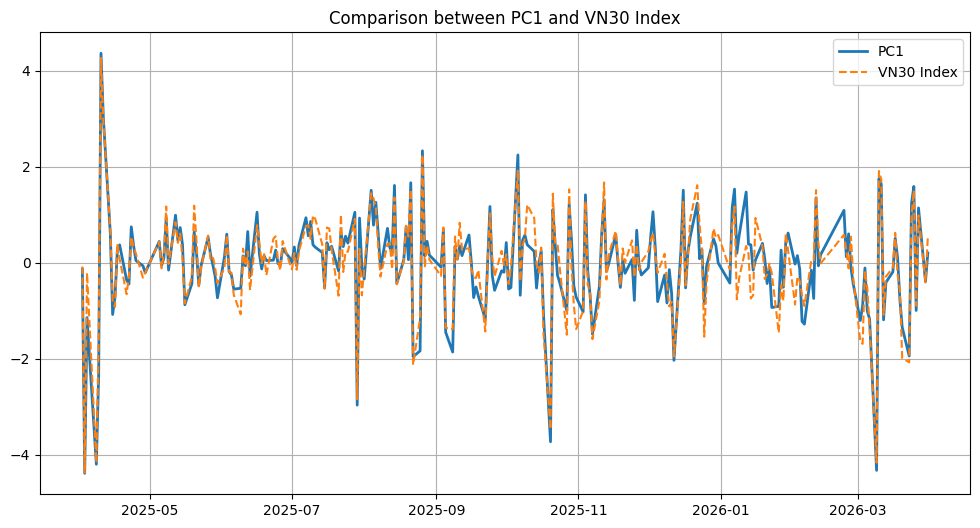

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(pc1_norm, label='PC1', linewidth=2)
plt.plot(vn30_norm, label='VN30 Index', linestyle='--')
plt.legend()
plt.title("Comparison between PC1 and VN30 Index")
plt.grid(True)
plt.show()

#  Correlation Analysis

Đánh giá mức độ tương quan giữa PC1 và VN30 Index.

Nếu PC1 thực sự đại diện cho yếu tố thị trường chung, nó sẽ có tương quan cao với VN30 Index.

In [ ]:
correlation = pc1_norm.corr(vn30_norm)
print("Correlation PC1 vs VN30:", correlation)

Correlation PC1 vs VN30: 0.9352567777248093


Mức tương quan rất cao giữa PC1 và VN30 cho thấy thị trường có tính hệ thống cao, nơi mà phần lớn cổ phiếu bị chi phối bởi một yếu tố chung.

Điều này hàm ý rằng việc đa dạng hóa trong phạm vi VN30 có thể không giúp giảm rủi ro đáng kể trong những giai đoạn thị trường biến động mạnh.

# 💡 Financial Insights

Kết quả cho thấy hệ số tương quan giữa PC1 và VN30 Index đạt mức rất cao (~0.93), cho thấy PC1 gần như phản ánh trực tiếp biến động của chỉ số thị trường.

Điều này chứng minh rằng PCA đã trích xuất thành công yếu tố thị trường chung (market factor) từ dữ liệu các cổ phiếu riêng lẻ.

Nói cách khác, phần lớn biến động của các cổ phiếu trong VN30 được chi phối bởi một yếu tố chung, thay vì các yếu tố riêng lẻ.

Kết quả này phù hợp với thực tế thị trường chứng khoán, khi các cổ phiếu vốn hóa lớn thường có xu hướng biến động cùng chiều theo xu hướng thị trường.

# Phân tích trọng số cổ phiếu (Loadings)

Các trọng số trong PC1 thể hiện mức độ đóng góp của từng cổ phiếu vào biến động chung của thị trường.

Những cổ phiếu có trọng số lớn hơn đóng vai trò quan trọng hơn trong việc dẫn dắt thị trường.

In [ ]:
pc1_loadings = pd.Series(eigenvectors[:, 0], index=stock_returns.columns)

pc1_loadings.sort_values(ascending=False).head(10)

,0
ACB,0.227205
CTG,0.226691
TCB,0.225138
TPB,0.223484
MBB,0.221949
VIB,0.221228
VPB,0.214043
MWG,0.213719
SSI,0.210477
HDB,0.207233


# 💡 Financial Insight từ PC1 Loadings

Kết quả cho thấy các cổ phiếu thuộc nhóm ngân hàng (ACB, CTG, TCB, MBB, VPB) có trọng số cao nhất trong PC1.

Điều này cho thấy nhóm ngân hàng đóng vai trò dẫn dắt biến động chung của thị trường chứng khoán Việt Nam trong giai đoạn phân tích.

Ngược lại, các cổ phiếu như VIC hoặc VJC có trọng số thấp hơn, cho thấy mức độ ảnh hưởng đến biến động thị trường chung là hạn chế hơn.

Kết quả này phản ánh thực tế khi nhóm ngân hàng thường có vốn hóa lớn và ảnh hưởng mạnh đến chỉ số VN30, từ đó chi phối xu hướng thị trường.

#  PC1 Loadings (Trọng số cổ phiếu vào PC1)

Phân tích sự đóng góp của từng cổ phiếu trong rổ VN30 vào xu hướng thị trường chung (PC1).

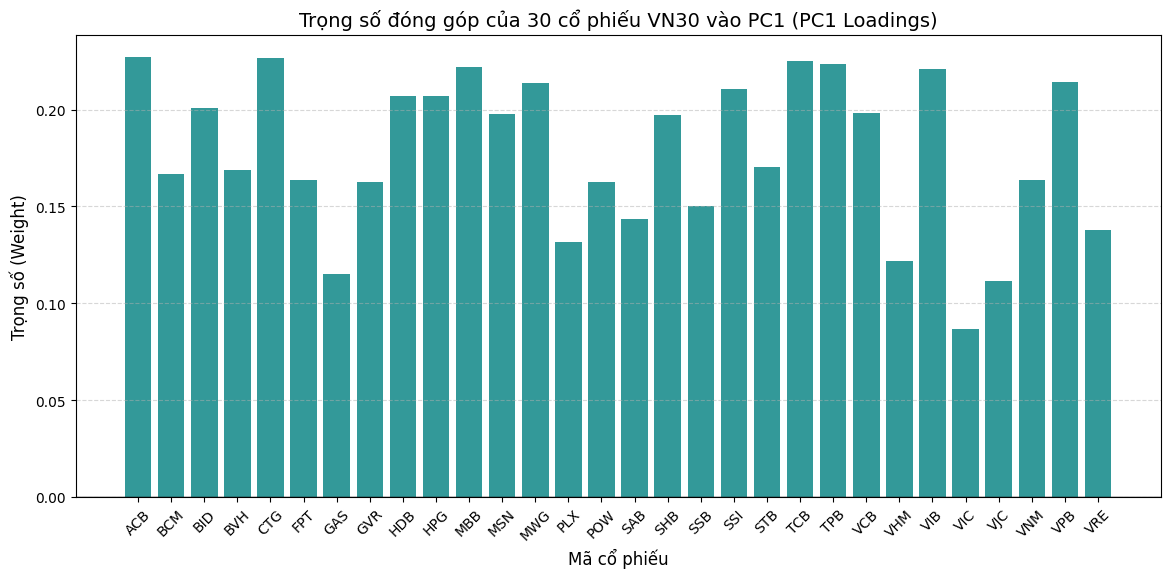

In [ ]:
# Lấy trọng số của PC1 (chính là Eigenvector đầu tiên, nhớ nhân -1 cho khớp chiều)
pc1_weights = eigenvectors[:, 0]

# Vẽ biểu đồ Bar Chart
plt.figure(figsize=(14, 6))
plt.bar(stock_returns.columns, pc1_weights, color='teal', alpha=0.8)
plt.title("Trọng số đóng góp của 30 cổ phiếu VN30 vào PC1 (PC1 Loadings)", fontsize=14)
plt.xlabel("Mã cổ phiếu", fontsize=12)
plt.ylabel("Trọng số (Weight)", fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Các trọng số (loadings) của PC1 đều mang dấu dương, cho thấy các cổ phiếu trong VN30 có xu hướng biến động cùng chiều.

Điều này phản ánh mức độ đồng bộ cao của thị trường, khi phần lớn cổ phiếu cùng tăng hoặc cùng giảm theo xu hướng chung.

Về mặt tài chính, kết quả này củng cố vai trò của PC1 như một “market factor”, đồng thời cho thấy rủi ro hệ thống (systematic risk) chiếm ưu thế so với rủi ro riêng lẻ của từng cổ phiếu.

# KẾT LUẬN

Phân tích PCA cho thấy thị trường chứng khoán Việt Nam có cấu trúc tương đối tập trung, với sự chi phối mạnh của một yếu tố thị trường chung (market factor).

Thành phần chính đầu tiên (PC1) có tương quan rất cao với VN30 Index, cho thấy PCA đã trích xuất hiệu quả biến động chung của thị trường. Đồng thời, các cổ phiếu ngân hàng có trọng số lớn trong PC1, phản ánh vai trò dẫn dắt của nhóm ngành này.

Kết quả này cho thấy biến động thị trường chủ yếu được quyết định bởi một số nhóm ngành trọng yếu, trong đó rủi ro hệ thống (systematic risk) đóng vai trò chi phối.

Về mặt ứng dụng, PCA có thể được sử dụng để:
- Xây dựng chỉ số đại diện thị trường,
- Giảm chiều dữ liệu cho các mô hình tài chính
- Hỗ trợ phân tích rủi ro danh mục đầu tư.